# Adaptive Nonlinear Vector Autoregression: Robust Forecasting for Noisy Chaotic Time Series
## Author
- **Name**: Azimov Sherkhon Azizkhon Ugli
- **Email**: sherxonazimov94@pusan.ac.kr
- **GitHub**: @AzimovSherkhon

Method: **Adaptive Nonlinear Vector Autoregression** 

Code: Prediction on unseen test data

Best Config Found: \
k=30, hidden_dim=500, Adam LR=1e-08, L-BFGS LR=0.1

In [1]:
# ============================================================
# Imports & Setup
# ============================================================
import warnings
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

# Torch defaults
torch.set_default_dtype(torch.float32)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device in use: {device}")
if device.type == "cuda":
    print(f"CUDA device: {torch.cuda.current_device()} - {torch.cuda.get_device_name(0)}")

# Suppress unnecessary warnings
warnings.filterwarnings("ignore", category=FutureWarning)

Device in use: cuda
CUDA device: 0 - A100-PCIE-40GB


(5001, 3)


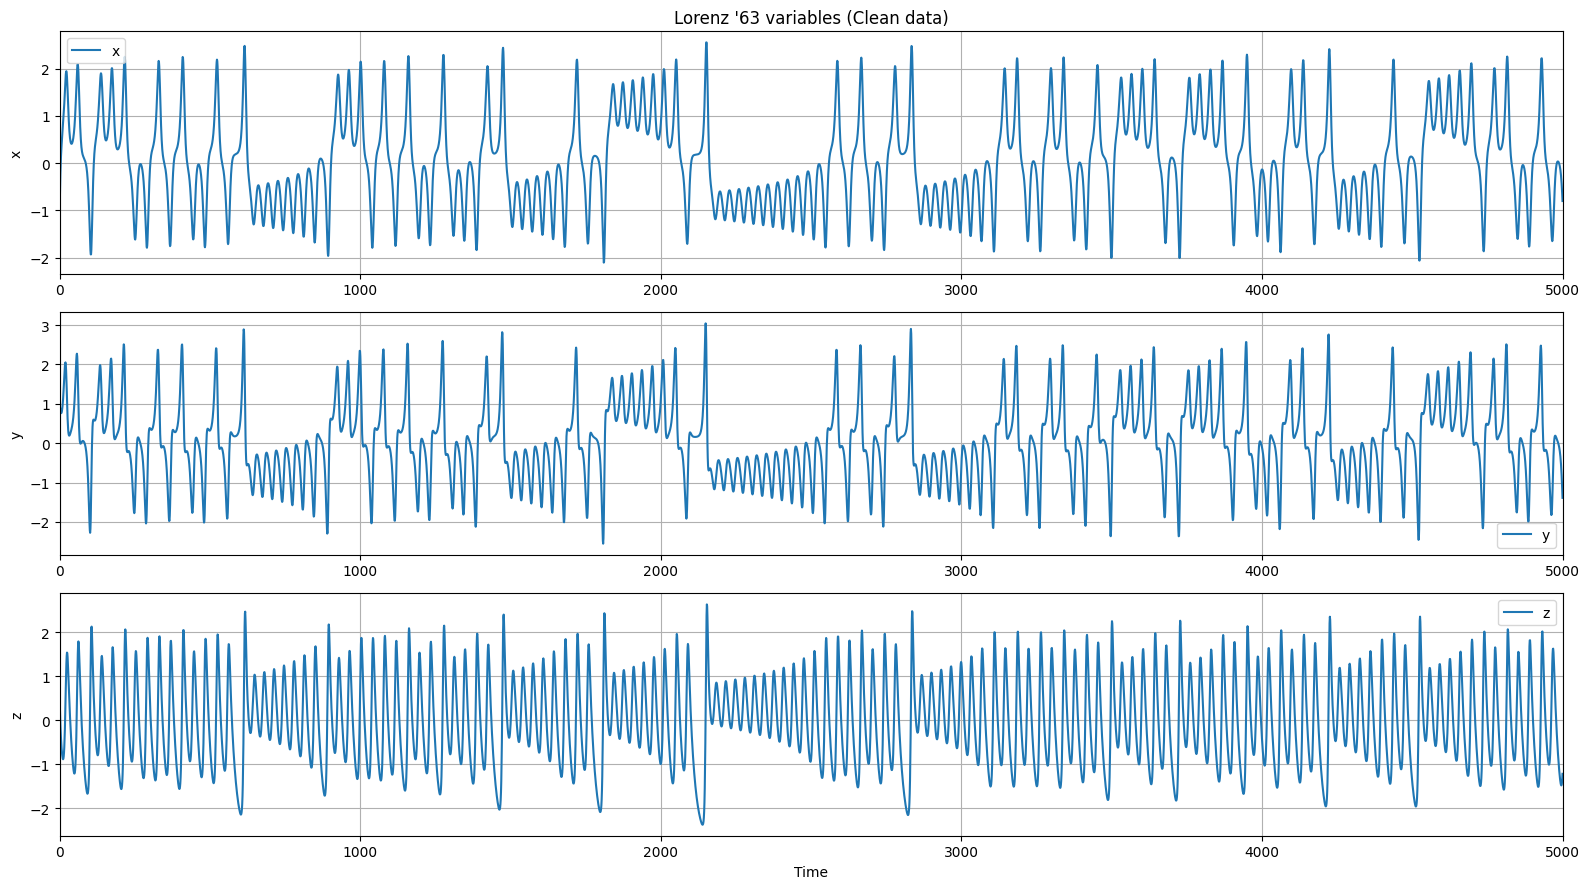

In [2]:
# ============================================================
# Load Lorenz 63 Clean Data
# ============================================================
data = np.load("lorenz63_noise_0.npy", allow_pickle=True).item()
l63_data = data["data"]   # (3, 5001)
meta = data["meta"]   # dict with warmup/train/val/test/mean/std
l63 = l63_data.T
print(l63.shape)

# ============================================================
# Visualization
# ============================================================
variables = ['x', 'y', 'z']
plt.figure(figsize=(16, 9))
for i in range(3):
    plt.subplot(3, 1, i + 1)
    plt.plot(l63.T[i], label=variables[i], color='C0')
    plt.ylabel(variables[i])
    plt.grid(True)
    if i == 0:
        plt.title("Lorenz '63 variables (Clean data)")
    if i == 2:
        plt.xlabel('Time')
    plt.legend()
    plt.xlim(0,5000)
plt.tight_layout()
plt.show()

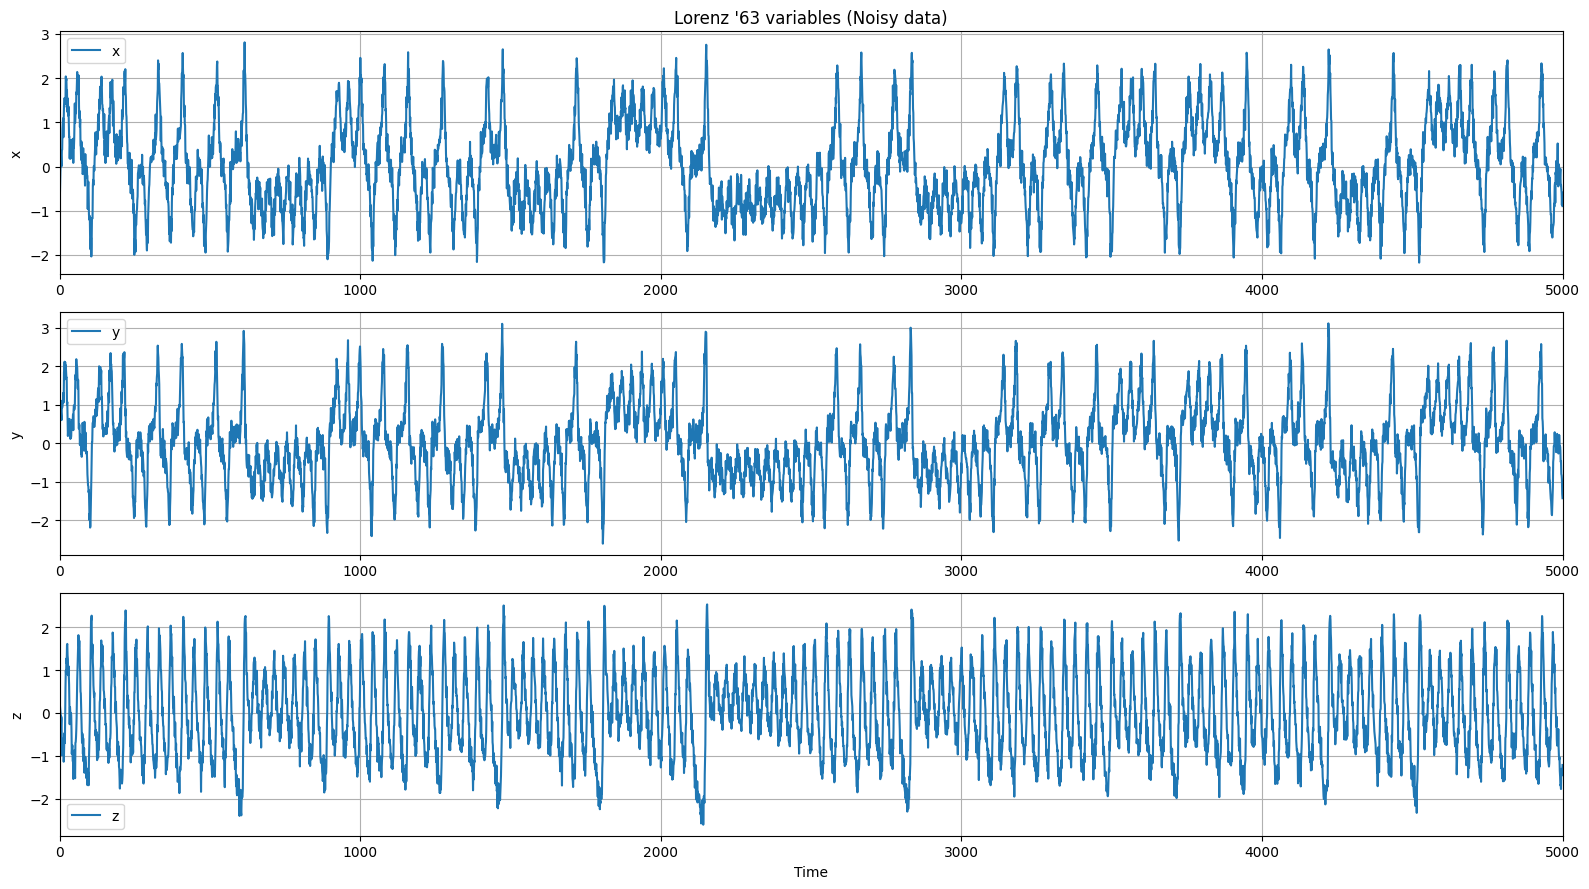

In [3]:
# ============================================================
# Reproducibility
# ============================================================
seed = 2025
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# # Load Lorenz 63 Noisy Data
# ============================================================
# Measurement noise (applied globally to dataset)
dataset_noise_scale = 0.20
data_noisy = np.load("lorenz63_noise_20.npy", allow_pickle=True).item()
X_noisy_dataset = data_noisy["data"]   # (3, 5001)
meta_noise = data["meta"]   # dict with warmup/train/val/test/mean/std
X_noisy_dataset = X_noisy_dataset.T

# ============================================================
# Visualization
# ============================================================
variables = ['x', 'y', 'z']
plt.figure(figsize=(16, 9))
for i in range(3):
    plt.subplot(3, 1, i + 1)
    plt.plot(X_noisy_dataset.T[i], label=variables[i], color='C0')
    plt.ylabel(variables[i])
    plt.grid(True)
    if i == 0:
        plt.title("Lorenz '63 variables (Noisy data)")
    if i == 2:
        plt.xlabel('Time')
    plt.legend()
    plt.xlim(0,5000)
plt.tight_layout()
plt.show()

X = torch.tensor(X_noisy_dataset, dtype=torch.float32)  # noisy input
X_true = torch.tensor(l63, dtype=torch.float32)          # clean reference

# Dataset splits
warmup_len, train_len, val_len, test_len = 100, 3900, 500, 500

X_warmup = X[:warmup_len].to(device)
X_train_clean = X[warmup_len:warmup_len + train_len]
X_val  = X[warmup_len + train_len : warmup_len + train_len + val_len].to(device)
X_test = X[warmup_len + train_len + val_len : warmup_len + train_len + val_len + test_len].to(device)

# Ground truth references
X_val_true  = X_true[warmup_len + train_len : warmup_len + train_len + val_len].to(device)
X_test_true = X_true[warmup_len + train_len + val_len : warmup_len + train_len + val_len + test_len].to(device)

# Training-time noise (works as a regularization only during training)
train_noise_scale = 0.0  # We only add it for noise free-case
signal_std = X_train_clean.std(dim=0, keepdim=True).cpu().numpy()
train_noise = np.random.normal(0.0, train_noise_scale * signal_std, X_train_clean.shape)
X_train = torch.tensor((X_train_clean.cpu().numpy() + train_noise).astype(np.float32), device=device)

In [4]:
# ============================================================
# Adaptive NVAR Model
# ============================================================
class FeatureMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)


class AdaptiveNVARModel(nn.Module):
    def __init__(self, dk, m, d, hidden_dim):
        super().__init__()
        self.mlp = FeatureMLP(dk, hidden_dim, m)
        self.readout = nn.Linear(dk + m, d, bias=False)

    def forward(self, H_lin):
        H_nn = self.mlp(H_lin)
        H_total = torch.cat([H_lin, H_nn], dim=1)
        return self.readout(H_total)


# ============================================================
# Helper Functions
# ============================================================
def construct_H_lin(X, k):
    """Constructs delay-embedded features from time series."""
    T = X.shape[0]
    return torch.cat([X[i:T - k + i] for i in range(k)], dim=1)


def init_weights_stable(m):
    """Stable Xavier initialization for linear layers."""
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
        with torch.no_grad():
            m.weight.mul_(1.0)


# ============================================================
# Training Function (Adam + L-BFGS)
# ============================================================
def train_joint_model_with_lbfgs(
    X, k, m, hidden_dim=200,
    lr_adam=1e-4, lr_lbfgs=1.0,
    max_epochs_adam=5000, num_epochs_lbfgs=50000,
    save_path="best_joint_model.pth",
    adam_patience=200, tolerance=1e-8,
    device=None
):
    """Train Adaptive NVAR model using Adam + L-BFGS optimization."""
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    X = X.to(device)

    # Prepare features & targets
    H_lin = construct_H_lin(X, k)       # [n, dk]
    Y = X[k:] - X[k-1:-1]               # [n, d]
    n, dk = H_lin.shape
    d = Y.shape[1]

    # Initialize model
    model = AdaptiveNVARModel(dk, m, d, hidden_dim).to(device)
    model.apply(init_weights_stable)

    # --- Phase 1: Adam ---
    optimizer = torch.optim.Adam(model.parameters(), lr=lr_adam)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=200)

    best_loss = float("inf")
    epochs_no_improve = 0

    for epoch in range(max_epochs_adam):
        model.train()
        Y_hat = model(H_lin)
        loss = F.mse_loss(Y_hat, Y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step(loss.item())

        if best_loss - loss.item() > tolerance:
            best_loss, epochs_no_improve = loss.item(), 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= adam_patience:
            break

    torch.save(model.state_dict(), save_path)

    # --- Phase 2: L-BFGS ---
    model.load_state_dict(torch.load(save_path))
    optimizer = torch.optim.LBFGS(
        model.parameters(),
        lr=lr_lbfgs,
        max_iter=20,            
        max_eval=None,          
        tolerance_grad=1e-07,    
        tolerance_change=1e-09,    
        history_size=20,           
        line_search_fn='strong_wolfe'         
    )

    best_loss, epochs_no_improve = float("inf"), 0

    def closure():
        optimizer.zero_grad()
        Y_hat = model(H_lin)
        loss = F.mse_loss(Y_hat, Y)
        loss.backward()
        return loss

    for epoch in range(num_epochs_lbfgs):
        model.train()
        loss = optimizer.step(closure)
        current_loss = loss.item()

        if best_loss - current_loss > tolerance:
            best_loss, epochs_no_improve = current_loss, 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= 200:
            break

    torch.save(model.state_dict(), save_path)
    return model

In [5]:
# ============================================================
# Test Prediction with Multiple Runs (Mean ± Std)
# ============================================================
# Best Config Found:
# k=30, hidden_dim=500, Adam LR=1e-08, L-BFGS LR=0.1
d = 3
k = 30
dk = d * k
m = (dk * (dk + 1)) // 2
hidden_dim = 500
lr_adam = 1e-8
lr_lbfgs = 0.1

horizons = [25, 50, 75, 100]

base_seed = 2025
num_runs = 5      # only for the DEMO (real: 25 runs)
num_windows = 5   # 100 steps per window → 500/100 = 5

print("\n=== Test Prediction over Multiple Runs ===")

all_run_rmses = {h: [] for h in horizons}  # RMSE storage across runs

runtime_start = time.perf_counter()
for run in range(num_runs):
    seed = base_seed + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"\n--- Run {run+1}/{num_runs} | Seed={seed} ---")

    # Unique model path per run
    model_path = f"model_k{k}_hd{hidden_dim}_adam{lr_adam}_lbfgs{lr_lbfgs}_noise{train_noise_scale}_run{run}.pth"

    # Train model
    model = train_joint_model_with_lbfgs(
        X_train, k=k, m=m, hidden_dim=hidden_dim,
        lr_adam=lr_adam, lr_lbfgs=lr_lbfgs,
        save_path=model_path
    )
    model.eval()

    window_size = len(X_test_true) // num_windows
    horizon_rmses = {h: [] for h in horizons}

    # Rollout predictions across test windows
    for w in range(num_windows):
        start, end = w * window_size, (w + 1) * window_size
        X_test_true_window = X_test_true[start:end]

        # Initialization: last k noisy points
        init_start = warmup_len + train_len + val_len + start - k
        init_end   = warmup_len + train_len + val_len + start
        X_init = X[init_start:init_end].to(device)

        x_t = [x.clone() for x in X_init.unbind(0)]
        H_lin = torch.cat(x_t, dim=-1).unsqueeze(0)

        predictions = []
        for _ in range(window_size):
            with torch.no_grad():
                delta_x = model(H_lin)
            x_next = x_t[-1] + delta_x.squeeze(0)
            predictions.append(x_next)

            # Update autoregressive state
            x_t = x_t[1:] + [x_next]
            H_lin = torch.cat(x_t, dim=-1).unsqueeze(0)

        predictions_np = torch.stack(predictions).cpu().numpy()
        y_true_np = X_test_true_window.cpu().numpy()

        # Horizon RMSEs for this window
        for h in horizons:
            if h <= window_size:
                rmse = np.sqrt(np.mean((y_true_np[:h] - predictions_np[:h]) ** 2))
                horizon_rmses[h].append(rmse)

    # Average RMSEs over windows for this run
    avg_rmse_run = {h: np.mean(horizon_rmses[h]) for h in horizons}
    for h in horizons:
        all_run_rmses[h].append(avg_rmse_run[h])

    print("Run RMSEs → " + ", ".join([f"h={h}: {avg_rmse_run[h]:.6f}" for h in horizons]))

runtime_end = time.perf_counter()
print("Runtime:", runtime_end - runtime_start, "seconds")
# ============================================================
# Final Results (Mean ± Std across runs)
# ============================================================
final_stats = {h: (np.mean(all_run_rmses[h]), np.std(all_run_rmses[h])) for h in horizons}

print("\n=== Final Results across Runs ===")
print(f"k={k}, hidden_dim={hidden_dim}, train_noise={train_noise_scale}")
for h in horizons:
    mean, std = final_stats[h]
    print(f"h={h}: {mean:.6f} ± {std:.6f}")




=== Test Prediction over Multiple Runs ===

--- Run 1/5 | Seed=2025 ---
Run RMSEs → h=25: 0.509865, h=50: 0.598056, h=75: 0.517279, h=100: 0.484218

--- Run 2/5 | Seed=2026 ---
Run RMSEs → h=25: 0.340907, h=50: 0.308454, h=75: 0.280733, h=100: 0.325850

--- Run 3/5 | Seed=2027 ---
Run RMSEs → h=25: 0.424670, h=50: 0.392013, h=75: 0.353426, h=100: 0.374056

--- Run 4/5 | Seed=2028 ---
Run RMSEs → h=25: 0.369154, h=50: 0.531712, h=75: 0.481562, h=100: 0.500320

--- Run 5/5 | Seed=2029 ---
Run RMSEs → h=25: 0.349919, h=50: 0.462365, h=75: 0.405908, h=100: 0.401356
Runtime: 111.55491711385548 seconds

=== Final Results across Runs ===
k=30, hidden_dim=500, train_noise=0.0
h=25: 0.398903 ± 0.062649
h=50: 0.458520 ± 0.101770
h=75: 0.407781 ± 0.085478
h=100: 0.417160 ± 0.066117


In [6]:
# ============================================================
# Reload Fixed Best Model (Manual Parameters)
# ============================================================
model_path = f"model_k{k}_hd{hidden_dim}_adam{lr_adam}_lbfgs{lr_lbfgs}_noise{train_noise_scale}_run{run}.pth"
best_model = AdaptiveNVARModel(dk=dk, m=m, d=d, hidden_dim=hidden_dim).to(device)
best_model.load_state_dict(torch.load(model_path, map_location=device))
best_model.eval()

all_preds, all_true, all_noisy = [], [], []

# ------------------------------------------------------------
# Rollout predictions across windows
# ------------------------------------------------------------
for w in range(num_windows):
    start, end = w * window_size, (w + 1) * window_size
    X_test_true_window = X_test_true[start:end]
    X_test_noisy_window = X_test[start:end]

    # Initialization with last k noisy points
    init_start = warmup_len + train_len + val_len + start - k
    init_end   = warmup_len + train_len + val_len + start
    X_init = X[init_start:init_end].to(device)

    x_t = [x.clone() for x in X_init.unbind(0)]
    H_lin = torch.cat(x_t, dim=-1).unsqueeze(0)

    predictions = []
    for _ in range(window_size):
        with torch.no_grad():
            delta_x = best_model(H_lin)
        x_next = x_t[-1] + delta_x.squeeze(0)
        predictions.append(x_next)

        # Update autoregressive state
        x_t = x_t[1:] + [x_next]
        H_lin = torch.cat(x_t, dim=-1).unsqueeze(0)

    all_preds.append(torch.stack(predictions).cpu().numpy())
    all_true.append(X_test_true_window.cpu().numpy())
    all_noisy.append(X_test_noisy_window.cpu().numpy())

# ------------------------------------------------------------
# Concatenate results
# ------------------------------------------------------------
preds_concat = np.concatenate(all_preds)
true_concat = np.concatenate(all_true)
noisy_concat = np.concatenate(all_noisy)

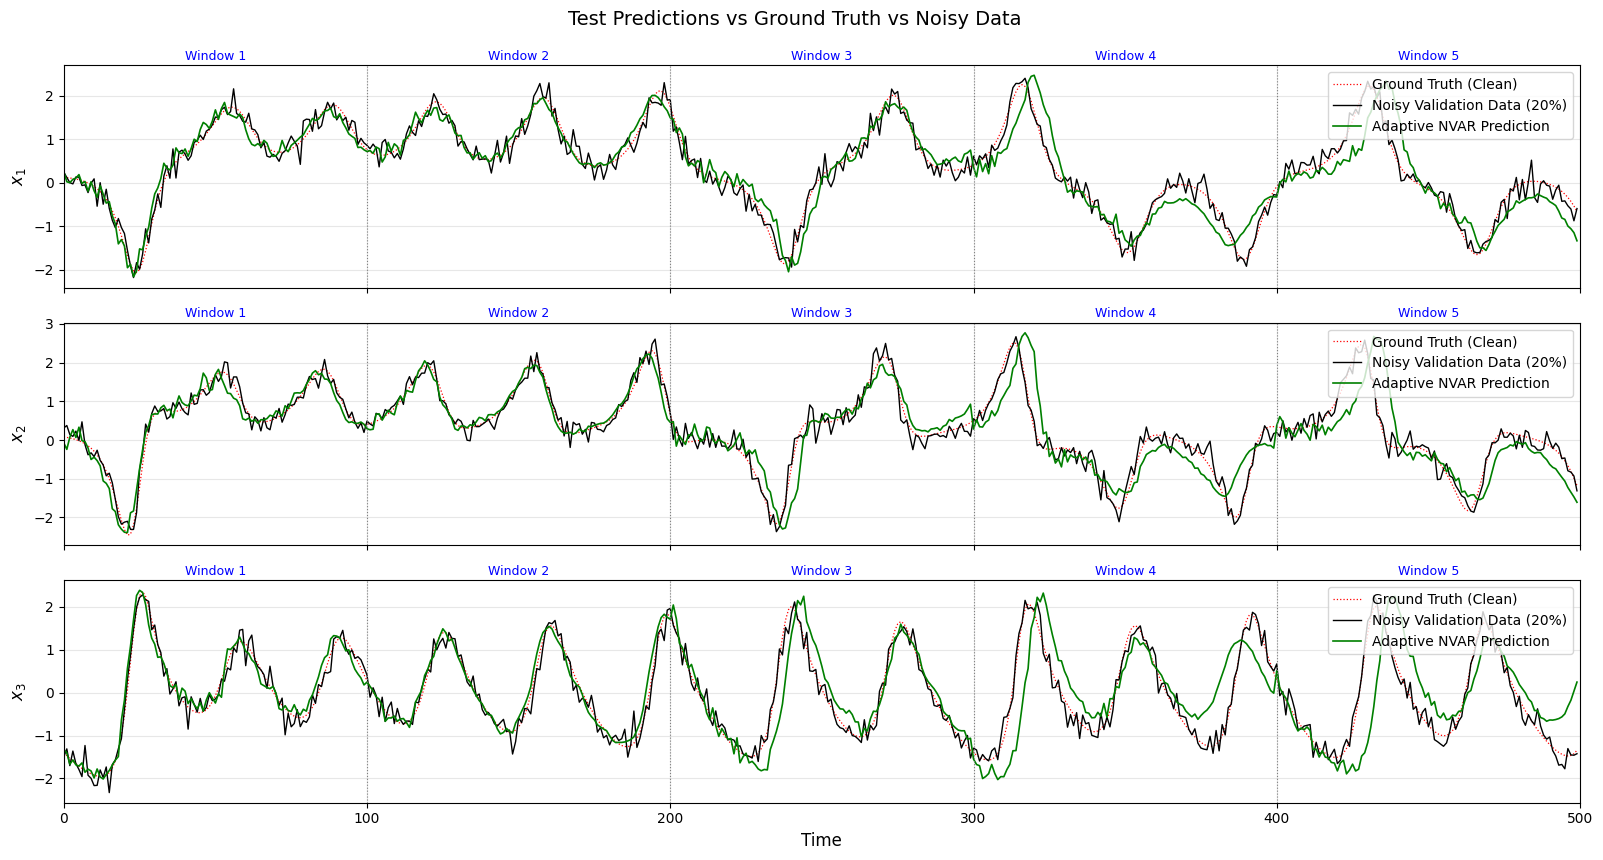

Saved plot as: test_pred_vs_truth_k30_hd500_noise0.20.png


In [7]:
# ============================================================
# Visualization (per variable)
# ============================================================

variables = [f"x_{i+1}" for i in range(true_concat.shape[1])]  # Auto-generate names

fig, axes = plt.subplots(len(variables), 1, figsize=(16, 3 * len(variables)), sharex=True)

if len(variables) == 1:
    axes = [axes]  # make iterable if only 1 variable

for i, ax in enumerate(axes):
    # Ground truth
    ax.plot(true_concat[:, i], label="Ground Truth (Clean)", color="red", linestyle=":", linewidth=0.9)

    # Noisy observations
    ax.plot(noisy_concat[:, i], label=f"Noisy Validation Data ({dataset_noise_scale*100:.0f}%)",
            color="black", linewidth=1.0, alpha=1.0)

    # Predictions
    ax.plot(preds_concat[:, i], label="Adaptive NVAR Prediction", color="green", linewidth=1.2)

    # Mark window boundaries
    for w in range(1, num_windows):
        ax.axvline(w * window_size, color="gray", linestyle="dotted", linewidth=0.8)

    # Label windows at the center
    ylim = ax.get_ylim()
    for w in range(num_windows):
        center = w * window_size + window_size // 2
        ax.text(center, ylim[1] * 1.02, f"Window {w+1}",
                ha="center", va="bottom", fontsize=9, color="blue")

    # Axis labels (LaTeX format)
    ax.set_ylabel(f"$x_{{{i+1}}}$", fontsize=12)
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Time", fontsize=12)
fig.suptitle("Test Predictions vs Ground Truth vs Noisy Data", fontsize=14, y=0.95)


plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.xlim(0, 500)

# Save and show
filename = f"test_pred_vs_truth_k{k}_hd{hidden_dim}_noise{dataset_noise_scale:.2f}.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved plot as: {filename}")
